# Lecture 4c — Bands, not calendars

**AI-powered Investment and Risk Management · Robo-Advisers and Automated Investment Platforms**

---

## The question

Notebook 4b handed each client a model portfolio. Markets then move, and by the end of the
first month nobody holds the portfolio they were sold.

Every platform therefore has a rebalancing rule, and the rules are strikingly consistent across
the industry: not "trade on the first of the month" but "trade when a sleeve drifts more than a
few percentage points from target". Drift bands, not calendars.

> **When should an automated platform actually trade, and what is it buying when it does?**

The second half of that question turns out to matter more than the first. There is a widespread
belief that rebalancing adds return — a "rebalancing bonus" harvested by systematically selling
what has risen and buying what has fallen. We will measure it. It is not there.

## The layer

This is the **execution** layer, first half. Notebook 4d takes the second half: what happens
when the account is taxable and every trade has a revenue consequence. The two are more tightly
coupled than they look, and section 5 is where they meet.

---

### How to use this notebook

* Runs end to end in **under 15 seconds**. No internet, no downloads.
* Prose is for a finance-first reader; mathematics sits in collapsible boxes.
* Exercises are tiered **Core** and **Stretch**.
* Uses the same asset universe and the same middle rung of the ladder as notebook 4b.


## 0 · Setup

The target portfolio below is the middle rung of the ladder derived in notebook 4b — the
portfolio a client with median risk aversion was handed. We simulate 400 clients over 25 years
of monthly returns and put eight rebalancing rules through the same paths.

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

SEED    = 20260811
MONTHS  = 300          # 25 years
PATHS   = 400
COST_BP = 10.0         # round-trip trading cost, bp per unit of portfolio traded

rng = np.random.default_rng(SEED)

ASSETS = ['AU equity', 'Intl equity', 'EM equity', 'Agg bonds', 'Cash']
MU  = np.array([0.080, 0.075, 0.085, 0.042, 0.035])
SD  = np.array([0.160, 0.150, 0.210, 0.055, 0.008])
CORR = np.array([
    [1.00, 0.72, 0.66, 0.05, 0.00],
    [0.72, 1.00, 0.74, 0.10, 0.00],
    [0.66, 0.74, 1.00, 0.08, 0.00],
    [0.05, 0.10, 0.08, 1.00, 0.15],
    [0.00, 0.00, 0.00, 0.15, 1.00]])
COV = np.outer(SD, SD) * CORR

TARGET     = np.array([0.33, 0.20, 0.06, 0.41, 0.00])   # rung 3 from notebook 4b
EQUITY_IDX = [0, 1, 2]

NAVY, BAND, RED, GREY, GOLD = '#123F69', '#E2EBF4', '#C0392B', '#7F8C8D', '#B7950B'
TEMPLATE = dict(layout=go.Layout(
    font=dict(family='Georgia, serif', size=13), plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#EEEEEE', zeroline=False),
    yaxis=dict(showgrid=True, gridcolor='#EEEEEE', zeroline=False),
    margin=dict(l=60, r=30, t=60, b=50)))

RETURNS = rng.multivariate_normal(MU / 12, COV / 12, size=(PATHS, MONTHS))
print(f"target portfolio: {dict(zip(ASSETS, (TARGET*100).round(0)))}")
print(f"target equity share: {TARGET[EQUITY_IDX].sum():.0%}")
print(f"simulated: {PATHS} clients x {MONTHS} months")

target portfolio: {'AU equity': np.float64(33.0), 'Intl equity': np.float64(20.0), 'EM equity': np.float64(6.0), 'Agg bonds': np.float64(41.0), 'Cash': np.float64(0.0)}
target equity share: 59%
simulated: 400 clients x 300 months


---

## 1 · The rebalancing engine

One function runs every rule. The four rules it supports are the four that appear in practice:

* **Never** — buy and hold. The baseline.
* **Calendar** — trade every $n$ months regardless of drift.
* **Drift band** — trade whenever any sleeve is more than $\delta$ from its target weight.
* **Banded calendar** — check quarterly, trade only if a band is breached. This is the rule most
  platforms actually run, because it bounds both the monitoring cost and the trading cost.

The `contribution` argument switches on a fifth mechanism that turns out to matter more than
any of them, but we leave it off until section 6.

In [2]:
def rebalance(rule, param=None, contribution=0.0, cost_bp=COST_BP):
    """Run one rebalancing rule across all simulated clients.

    rule : 'never' | 'calendar' | 'band' | 'banded_calendar'
    param: months between trades (calendar) or drift tolerance in decimals (band)
    contribution: annual contribution as a fraction of current wealth, directed to
                  whichever sleeves are underweight
    """
    P, Mn, A = RETURNS.shape
    w    = np.tile(TARGET, (P, 1)).astype(float)     # current weights
    val  = np.ones(P)                                # portfolio value, indexed to 1
    turnover = np.zeros(P)
    trades   = np.zeros(P)
    drift    = np.zeros((P, Mn))
    eq_path  = np.zeros((P, Mn))

    for m in range(Mn):
        w   = w * (1 + RETURNS[:, m, :])             # markets move
        val = val * w.sum(axis=1)
        w   = w / w.sum(axis=1, keepdims=True)

        if contribution > 0:                         # deposit buys the underweight sleeves
            c   = contribution / 12
            gap = np.clip(TARGET - w, 0, None)
            tot = gap.sum(axis=1, keepdims=True)
            gap = np.divide(gap, tot, out=np.tile(TARGET, (P, 1)), where=tot > 1e-12)
            w   = (w + c * gap) / (1 + c)
            val = val * (1 + c)

        dev = np.abs(w - TARGET)
        drift[:, m]   = np.sqrt(((w - TARGET) ** 2).sum(axis=1))
        eq_path[:, m] = w[:, EQUITY_IDX].sum(axis=1)

        if   rule == 'never':    hit = np.zeros(P, bool)
        elif rule == 'calendar': hit = np.full(P, (m + 1) % param == 0)
        elif rule == 'band':     hit = dev.max(axis=1) > param
        elif rule == 'banded_calendar': hit = ((m + 1) % 3 == 0) & (dev.max(axis=1) > param)
        else: raise ValueError(rule)

        if hit.any():
            traded = np.abs(w[hit] - TARGET).sum(axis=1) / 2      # one-way turnover
            turnover[hit] += traded
            trades[hit]   += 1
            val[hit]      *= (1 - traded * cost_bp / 1e4)
            w[hit]         = TARGET

    years = Mn / 12
    cagr  = val ** (1 / years) - 1
    return dict(turnover=turnover.mean() / years * 100,
                tracking=drift.mean() * 100,
                trades_pa=trades.mean() / years,
                cagr=cagr.mean() * 100,
                cagr_sd=cagr.std() * 100,
                final_equity=eq_path[:, -1].mean() * 100,
                equity_paths=eq_path)

RULES = [('Never rebalance',          dict(rule='never')),
         ('Monthly',                  dict(rule='calendar', param=1)),
         ('Quarterly',                dict(rule='calendar', param=3)),
         ('Annual',                   dict(rule='calendar', param=12)),
         ('Band 1pp',                 dict(rule='band', param=0.01)),
         ('Band 3pp',                 dict(rule='band', param=0.03)),
         ('Band 5pp',                 dict(rule='band', param=0.05)),
         ('Band 5pp, checked qtrly',  dict(rule='banded_calendar', param=0.05))]

results = {label: rebalance(**kw) for label, kw in RULES}
summary = pd.DataFrame([{
    'Rule': k,
    'Turnover % p.a.':  round(v['turnover'], 2),
    'Tracking error %': round(v['tracking'], 2),
    'Trades p.a.':      round(v['trades_pa'], 2),
    'CAGR %':           round(v['cagr'], 3),
    'CAGR sd %':        round(v['cagr_sd'], 3),
    'Final equity %':   round(v['final_equity'], 1)} for k, v in results.items()])
print(summary.to_string(index=False))

                   Rule  Turnover % p.a.  Tracking error %  Trades p.a.  CAGR %  CAGR sd %  Final equity %
        Never rebalance             0.00             15.29         0.00   6.283      2.411            71.1
                Monthly            12.51              1.26        12.00   6.114      1.965            59.1
              Quarterly             7.23              1.73         4.00   6.121      1.966            59.2
                 Annual             3.65              3.07         1.00   6.132      1.985            59.5
               Band 1pp             9.43              1.38         5.69   6.118      1.964            59.1
               Band 3pp             4.50              2.23         1.22   6.126      1.975            59.2
               Band 5pp             2.89              3.23         0.50   6.130      1.978            59.3
Band 5pp, checked qtrly             2.64              3.50         0.43   6.128      1.986            59.3


---

## 2 · What happens if you never trade

Start with the baseline, because it frames everything else. Left alone for 25 years, the
portfolio does not stay where it was put.

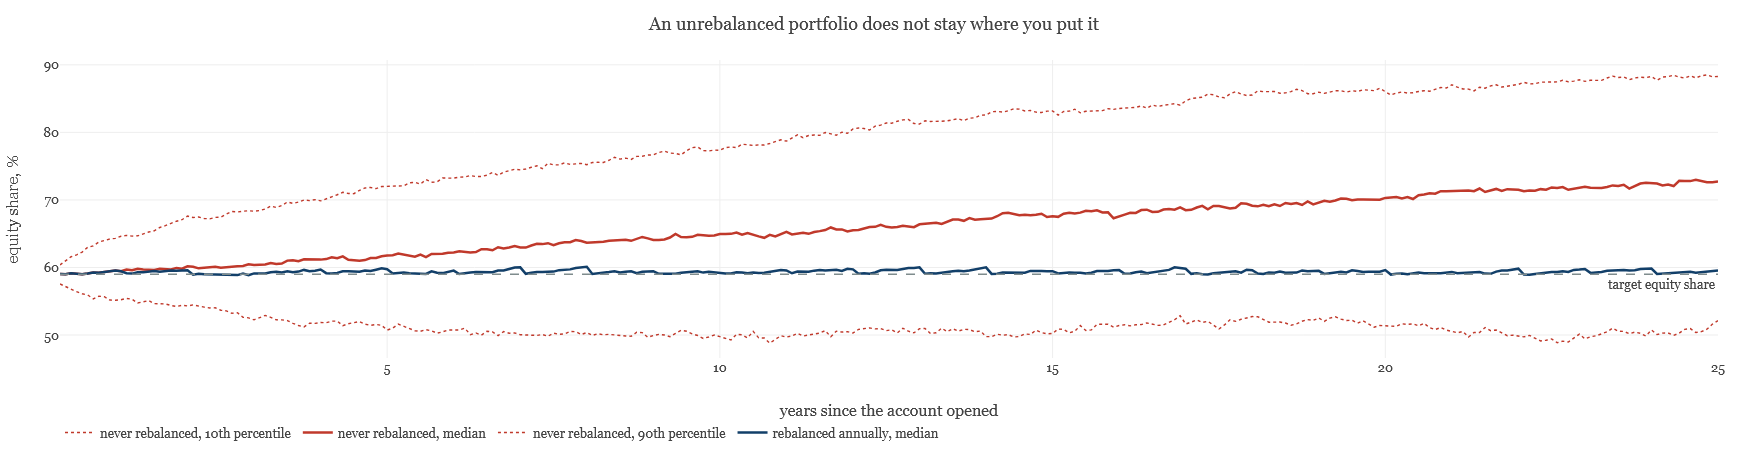

After 25 years without rebalancing, the median client holds 73% equity against a 59% target.
The 10th-90th percentile range is 52% to 88%.


In [3]:
eq = results['Never rebalance']['equity_paths'] * 100
eq_annual = results['Annual']['equity_paths'] * 100
months = np.arange(1, MONTHS + 1) / 12

fig = go.Figure()
for q, nm, dash in [(10, '10th percentile', 'dot'), (50, 'median', 'solid'), (90, '90th percentile', 'dot')]:
    fig.add_trace(go.Scatter(x=months, y=np.percentile(eq, q, axis=0), mode='lines', name=f'never rebalanced, {nm}',
                             line=dict(color=RED, width=2.5 if q == 50 else 1.4, dash=dash),
                             hovertemplate='year %{x:.1f}<br>equity %{y:.1f}%<extra></extra>'))
fig.add_trace(go.Scatter(x=months, y=np.percentile(eq_annual, 50, axis=0), mode='lines',
                         name='rebalanced annually, median', line=dict(color=NAVY, width=2.5)))
fig.add_hline(y=TARGET[EQUITY_IDX].sum() * 100, line=dict(color=GREY, width=1.5, dash='dash'),
              annotation_text='target equity share', annotation_position='bottom right')
fig.update_layout(template=TEMPLATE, height=460,
                  title_text='An unrebalanced portfolio does not stay where you put it',
                  xaxis_title='years since the account opened', yaxis_title='equity share, %',
                  legend=dict(orientation='h', y=-0.2))
fig.show()

nr = results['Never rebalance']
print(f"After 25 years without rebalancing, the median client holds "
      f"{np.percentile(eq[:, -1], 50):.0f}% equity against a {TARGET[EQUITY_IDX].sum():.0%} target.")
print(f"The 10th-90th percentile range is "
      f"{np.percentile(eq[:, -1], 10):.0f}% to {np.percentile(eq[:, -1], 90):.0f}%.")

This is the case for rebalancing, and it is a strong one — but notice precisely what it says.
The unrebalanced client has not been *cheated*; they have been silently migrated into a
different risk profile. A platform that assessed someone as a balanced investor and then let
them drift to three-quarters equity has stopped delivering the advice it documented.

That is a compliance problem before it is an investment problem. Under RG 255 a licensee must
be able to explain why a client holds what they hold. "Because we recommended 59% equity eleven
years ago and never looked again" is not an explanation that survives contact with a review.

---

## 3 · Does rebalancing add return?

Now the claim that will not die. Selling what has risen and buying what has fallen sounds like
buying low and selling high, and a large body of practitioner writing calls the resulting gain
a "rebalancing bonus" or "diversification return".

Look at the CAGR column in the table from section 1.

In [4]:
comp = summary[['Rule', 'CAGR %', 'CAGR sd %', 'Final equity %', 'Turnover % p.a.']].copy()
comp['CAGR vs never (bp)'] = ((comp['CAGR %'] - summary.loc[0, 'CAGR %']) * 100).round(0)
print(comp.to_string(index=False))

reb = summary[summary['Rule'] != 'Never rebalance']
print(f"\nSpread of CAGR across the seven rebalancing rules: "
      f"{(reb['CAGR %'].max() - reb['CAGR %'].min()) * 100:.1f} bp p.a.")
print(f"Never rebalancing beat every one of them, by "
      f"{(summary.loc[0, 'CAGR %'] - reb['CAGR %'].max()) * 100:.0f} to "
      f"{(summary.loc[0, 'CAGR %'] - reb['CAGR %'].min()) * 100:.0f} bp p.a.")
print(f"\nBut it did so holding {summary.loc[0, 'Final equity %']:.0f}% equity at the end, "
      f"not {reb['Final equity %'].mean():.0f}%,")
print(f"and with a dispersion of outcomes {summary.loc[0, 'CAGR sd %'] / reb['CAGR sd %'].mean() - 1:.0%} wider.")

                   Rule  CAGR %  CAGR sd %  Final equity %  Turnover % p.a.  CAGR vs never (bp)
        Never rebalance   6.283      2.411            71.1             0.00                 0.0
                Monthly   6.114      1.965            59.1            12.51               -17.0
              Quarterly   6.121      1.966            59.2             7.23               -16.0
                 Annual   6.132      1.985            59.5             3.65               -15.0
               Band 1pp   6.118      1.964            59.1             9.43               -17.0
               Band 3pp   6.126      1.975            59.2             4.50               -16.0
               Band 5pp   6.130      1.978            59.3             2.89               -15.0
Band 5pp, checked qtrly   6.128      1.986            59.3             2.64               -16.0

Spread of CAGR across the seven rebalancing rules: 1.8 bp p.a.
Never rebalancing beat every one of them, by 15 to 17 bp p.a.

But it di

The unrebalanced portfolio won. It won because it drifted into more equity, and equity has a
higher expected return in these assumptions. It is not a better strategy; it is a *different,
riskier* portfolio, and it was compensated for the extra risk in the ordinary way.

Among the rules that actually hold the risk profile constant, the return differences are a few
basis points — noise. Rebalancing did not add return, and there was never a mechanism by which
it could.

<details>
<summary><b>Where the "rebalancing bonus" actually comes from (click to open)</b></summary>

The claim rests on the gap between the arithmetic and geometric mean. A rebalanced portfolio's
expected log return exceeds the weighted average of the constituents' expected log returns by

$$\tfrac{1}{2}\left(\sum_i w_i \sigma_i^{2} - w'\Sigma w\right)$$

which is non-negative and often called the diversification return. It is real, but it is a
**diversification** effect, not a **rebalancing** effect: it is the benefit of holding a
portfolio rather than a single asset, and an unrebalanced portfolio captures it too for as long
as its weights remain diversified.

The genuinely rebalancing-specific component requires mean reversion in relative asset prices.
Our simulated returns are independent across time by construction, so that component is exactly
zero here — which is why the measured differences are noise. In real data the evidence for it
is weak, horizon-dependent, and swamped by the drift effect above.

The honest statement: **rebalancing is a risk-control device.** It keeps the client in the
portfolio they were sold. Any return it appears to add or subtract is a consequence of the risk
it added or subtracted.
</details>

---

## 4 · The frontier

If rebalancing is about risk control, the design question becomes an efficiency question. Every
rule trades off two quantities: how closely the client tracks their target, and how much
turnover it takes to keep them there. Plot one against the other and the rules sort themselves.

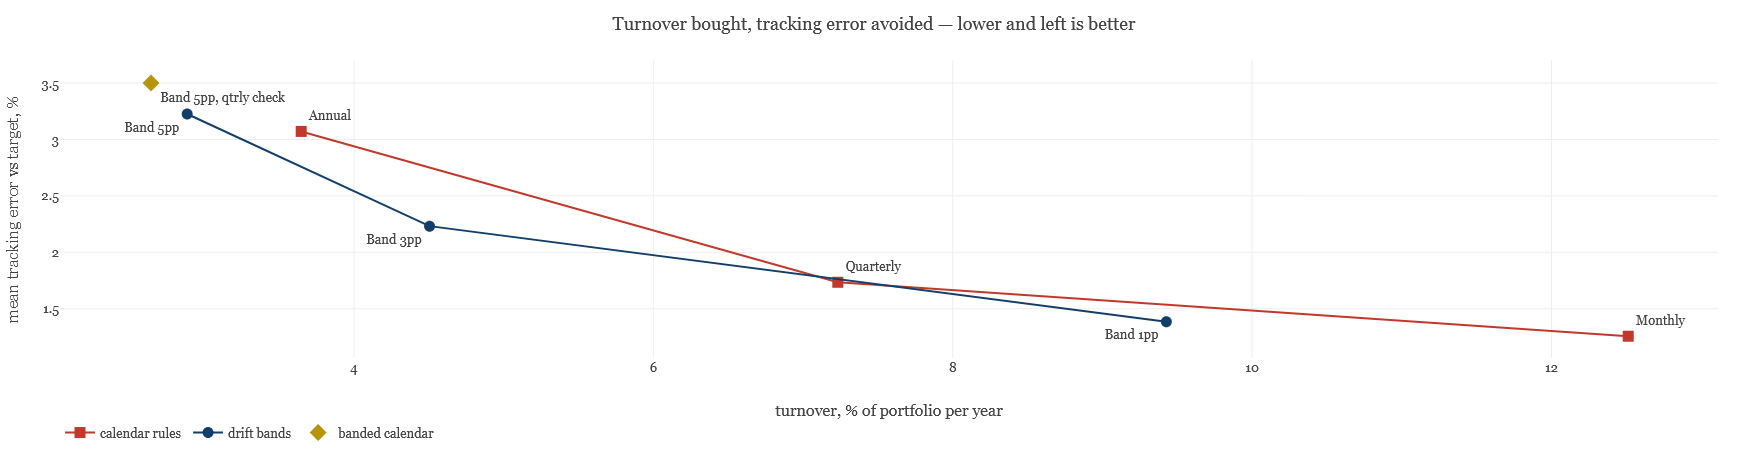

Band 5pp   vs Annual    : turnover 2.9% vs 3.6%   tracking 3.23% vs 3.07%   trades 0.5 vs 1.0 p.a.
Band 3pp   vs Quarterly : turnover 4.5% vs 7.2%   tracking 2.23% vs 1.73%   trades 1.2 vs 4.0 p.a.
Band 1pp   vs Monthly   : turnover 9.4% vs 12.5%   tracking 1.38% vs 1.26%   trades 5.7 vs 12.0 p.a.


In [5]:
fig = go.Figure()
cal = [r for r in ['Monthly', 'Quarterly', 'Annual']]
bnd = [r for r in ['Band 1pp', 'Band 3pp', 'Band 5pp']]

fig.add_trace(go.Scatter(x=[results[r]['turnover'] for r in cal], y=[results[r]['tracking'] for r in cal],
                         mode='lines+markers+text', name='calendar rules', text=cal, textposition='top right',
                         line=dict(color=RED, width=2), marker=dict(size=11, symbol='square'),
                         hovertemplate='%{text}<br>turnover %{x:.1f}%<br>tracking %{y:.2f}%<extra></extra>'))
fig.add_trace(go.Scatter(x=[results[r]['turnover'] for r in bnd], y=[results[r]['tracking'] for r in bnd],
                         mode='lines+markers+text', name='drift bands', text=bnd, textposition='bottom left',
                         line=dict(color=NAVY, width=2), marker=dict(size=11),
                         hovertemplate='%{text}<br>turnover %{x:.1f}%<br>tracking %{y:.2f}%<extra></extra>'))
r = 'Band 5pp, checked qtrly'
fig.add_trace(go.Scatter(x=[results[r]['turnover']], y=[results[r]['tracking']], mode='markers+text',
                         name='banded calendar', text=['Band 5pp, qtrly check'], textposition='bottom right',
                         marker=dict(size=13, color=GOLD, symbol='diamond')))
fig.update_layout(template=TEMPLATE, height=460,
                  title_text='Turnover bought, tracking error avoided — lower and left is better',
                  xaxis_title='turnover, % of portfolio per year',
                  yaxis_title='mean tracking error vs target, %',
                  legend=dict(orientation='h', y=-0.2))
fig.show()

for a, b in [('Annual', 'Band 5pp'), ('Quarterly', 'Band 3pp'), ('Monthly', 'Band 1pp')]:
    ra, rb = results[a], results[b]
    print(f"{b:<10} vs {a:<10}: turnover {rb['turnover']:.1f}% vs {ra['turnover']:.1f}%   "
          f"tracking {rb['tracking']:.2f}% vs {ra['tracking']:.2f}%   "
          f"trades {rb['trades_pa']:.1f} vs {ra['trades_pa']:.1f} p.a.")

Be careful reading this chart, because the advantage is narrower than the industry's enthusiasm
for bands suggests. Bands sit consistently to the **left** of the calendar rules — less turnover
— but slightly **above** them on tracking error. At the patient end the band genuinely wins:
interpolating the band curve to annual rebalancing's turnover gives about 2.8% tracking against
annual's 3.07%. Around quarterly turnover the two curves are indistinguishable.

The consistent advantage is in the third column of the table above, not on this chart. Compare
trade counts at similar outcomes: 0.5 against 1.0 a year, 1.2 against 4.0, 5.7 against 12.0.
Bands achieve comparable tracking with **a third to a quarter of the trading events**. A calendar
rule fires whether or not the portfolio needs it; a band rule fires only on the paths that
drifted, so the cost falls on the clients who generated it.

Bands also have a property calendars lack: they respond to volatility. A quiet year produces no
trades; a violent one produces several, exactly when the drift is worth correcting. No parameter
has to be re-tuned for this to happen.

---

## 5 · When does the cost actually bite?

At the trading costs assumed so far, none of this matters much. Monthly rebalancing turns over
about 12% of the portfolio a year, and at 10 bp that is a bit over one basis point of drag.

So why does the industry use wide bands rather than simply rebalancing monthly?

Because in a **taxable** account, turnover is not priced at the spread. It is priced at the
capital gains tax on whatever gain is embedded in the units you sell.

In [6]:
EMBEDDED_GAIN = 0.30    # share of a typical sold position that is unrealised gain
AU_RATE       = 0.47    # top marginal rate
CGT_DISCOUNT  = 0.50    # 50% discount on assets held over 12 months
EFFECTIVE_CGT = AU_RATE * (1 - CGT_DISCOUNT)

rows = []
for label, _ in RULES:
    t = results[label]['turnover'] / 100
    rows.append({'Rule': label,
                 'Turnover % p.a.': round(t * 100, 2),
                 'Trading cost (bp)': round(t * COST_BP, 2),
                 'CGT cost (bp)': round(t * EMBEDDED_GAIN * EFFECTIVE_CGT * 1e4, 1),
                 'Ratio': '-' if t == 0 else f"{EMBEDDED_GAIN * EFFECTIVE_CGT * 1e4 / COST_BP:.0f}x"})
costs = pd.DataFrame(rows)
print(f"Effective CGT rate on a discounted gain: {EFFECTIVE_CGT:.1%}\n")
print(costs.to_string(index=False))
print(f"\nIn a taxable account, a unit of turnover costs "
      f"{EMBEDDED_GAIN * EFFECTIVE_CGT * 1e4 / COST_BP:.0f} times what it costs in a tax-sheltered one.")

Effective CGT rate on a discounted gain: 23.5%

                   Rule  Turnover % p.a.  Trading cost (bp)  CGT cost (bp) Ratio
        Never rebalance             0.00               0.00            0.0     -
                Monthly            12.51               1.25           88.2   70x
              Quarterly             7.23               0.72           51.0   70x
                 Annual             3.65               0.36           25.7   70x
               Band 1pp             9.43               0.94           66.5   70x
               Band 3pp             4.50               0.45           31.8   70x
               Band 5pp             2.89               0.29           20.3   70x
Band 5pp, checked qtrly             2.64               0.26           18.6   70x

In a taxable account, a unit of turnover costs 70 times what it costs in a tax-sheltered one.


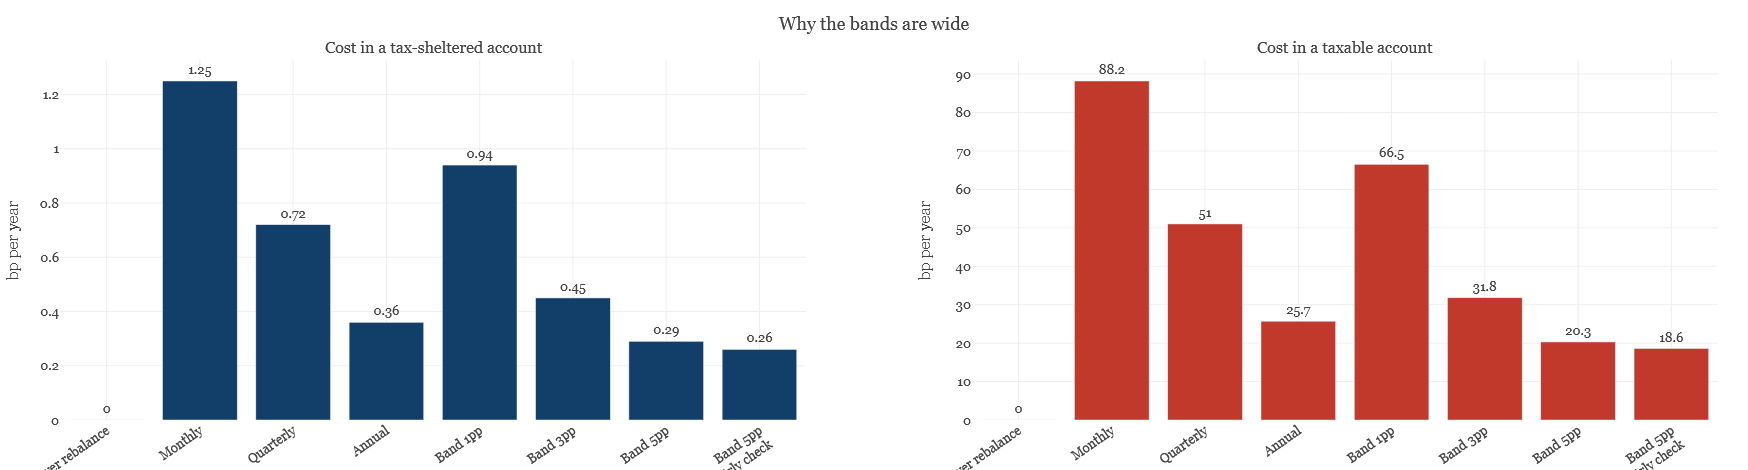

In [7]:
fig = make_subplots(rows=1, cols=2, subplot_titles=(
    'Cost in a tax-sheltered account', 'Cost in a taxable account'), shared_yaxes=False)
labels = [l for l, _ in RULES]
short = [l.replace(', checked qtrly', '<br>qtrly check') for l in labels]
fig.add_trace(go.Bar(x=short, y=costs['Trading cost (bp)'], marker_color=NAVY, showlegend=False,
                     text=costs['Trading cost (bp)'], textposition='outside',
                     hovertemplate='%{x}<br>%{y:.2f} bp<extra></extra>'), row=1, col=1)
fig.add_trace(go.Bar(x=short, y=costs['CGT cost (bp)'], marker_color=RED, showlegend=False,
                     text=costs['CGT cost (bp)'], textposition='outside',
                     hovertemplate='%{x}<br>%{y:.1f} bp<extra></extra>'), row=1, col=2)
fig.update_yaxes(title_text='bp per year', row=1, col=1)
fig.update_yaxes(title_text='bp per year', row=1, col=2)
fig.update_layout(template=TEMPLATE, height=470, title_text='Why the bands are wide')
fig.update_xaxes(tickangle=-35)
fig.show()

There is the answer. In superannuation, where the rate is 15% and often lower after the
discount, monthly rebalancing is close to free and the band width barely matters. In a taxable
individual account at the top marginal rate, the same rule costs well over a hundred basis
points a year — several times the platform's entire management fee.

This is why a serious platform does not have *a* rebalancing rule. It has one rule for
superannuation accounts and a different, much wider one for taxable accounts, and the
difference between them is worth more than any refinement of the optimiser in notebook 4b.

It is also the bridge to notebook 4d. Once you accept that the tax consequence of a trade
dominates its trading cost, the natural next question is whether you can make the tax
consequence work *for* the client rather than against them. That is tax-loss harvesting, and it
is where the Australian rules diverge sharply from the American ones this logic was built on.

---

## 6 · The mechanism nobody teaches: cash-flow rebalancing

One thing remains, and for an accumulating client it dominates every rule above.

A client contributing regularly does not need to sell anything to rebalance. The deposit can be
directed to whichever sleeves are underweight. No sale, no realised gain, no tax, no spread.
The rebalancing is free.

In [8]:
CONTRIB = 0.08     # 8% of wealth contributed each year

cash_rules = ['Never rebalance', 'Annual', 'Band 5pp', 'Band 3pp']
with_flow = {}
for label in cash_rules:
    kw = dict(next(k for l, k in RULES if l == label))
    with_flow[label] = rebalance(contribution=CONTRIB, **kw)

rows = []
for label in cash_rules:
    a, b = results[label], with_flow[label]
    rows.append({'Rule': label,
                 'Turnover, no contributions': round(a['turnover'], 2),
                 'Turnover, with contributions': round(b['turnover'], 2),
                 'Reduction': f"{1 - b['turnover'] / a['turnover']:.0%}" if a['turnover'] > 0 else '-',
                 'Tracking, no contrib': round(a['tracking'], 2),
                 'Tracking, with contrib': round(b['tracking'], 2)})
print(f"Client contributing {CONTRIB:.0%} of wealth per year:\n")
print(pd.DataFrame(rows).to_string(index=False))

nr_a, nr_b = results['Never rebalance']['tracking'], with_flow['Never rebalance']['tracking']
print(f"\nContributions alone, with NO trading at all, cut tracking error from "
      f"{nr_a:.1f}% to {nr_b:.1f}% - a {1 - nr_b/nr_a:.0%} reduction.")
b5a, b5b = results['Band 5pp'], with_flow['Band 5pp']
print(f"A 5pp band with contributions needs {b5b['turnover']:.2f}% turnover a year "
      f"instead of {b5a['turnover']:.2f}%, and {b5b['trades_pa']:.2f} trades instead of {b5a['trades_pa']:.2f}.")

Client contributing 8% of wealth per year:

           Rule  Turnover, no contributions  Turnover, with contributions Reduction  Tracking, no contrib  Tracking, with contrib
Never rebalance                        0.00                          0.00         -                 15.29                    2.62
         Annual                        3.65                          1.80       51%                  3.07                    1.73
       Band 5pp                        2.89                          0.62       79%                  3.23                    2.04
       Band 3pp                        4.50                          1.68       63%                  2.23                    1.59

Contributions alone, with NO trading at all, cut tracking error from 15.3% to 2.6% - a 83% reduction.
A 5pp band with contributions needs 0.62% turnover a year instead of 2.89%, and 0.11 trades instead of 0.50.


Read the first line again. A client who contributes regularly and **never trades at all** ends
up tracking their target better than a client who rebalances annually but does not contribute.
The deposits did the work.

Combine the two and the trading almost disappears: a 5-percentage-point band on a contributing
client fires roughly once a decade. Everything else is handled by directing the next deposit.

This is why cash-flow rebalancing is standard in every serious platform and why it is worth more
than the choice of band width. It is also a reason the robo-advice model fits accumulators
better than decumulators: a client drawing down has the same mechanism available in reverse —
fund withdrawals from the overweight sleeve — but a client who neither contributes nor withdraws
has no free rebalancing at all, and is exactly the client for whom the taxable-account arithmetic
in section 5 bites hardest.

---

## 7 · What this means for design

**Rebalancing is risk control, not return generation.** Every rule that held the risk profile
constant produced the same return to within a few basis points. The only rule that beat them
did so by abandoning the risk profile. Anyone quoting a rebalancing bonus should be asked
whether they held the equity share constant while measuring it.

**Bands beat calendars, modestly and for good reasons.** Lower turnover for the same tracking
error, fewer trades, costs falling on the clients who caused them, and automatic responsiveness
to volatility without re-tuning.

**Tax, not spread, sets the band width.** At institutional trading costs the choice of rule is
worth about a basis point. In a taxable Australian account at the top marginal rate it is worth
more than the entire management fee. A platform with a single rebalancing rule across account
types has not thought about this.

**Contributions do most of the work.** For an accumulating client, directing deposits removes
around 80% of the required turnover. This is the cheapest improvement available anywhere in the
pipeline, and it is a plumbing decision rather than a modelling one.

**What this notebook does not show.** Returns here are independent across time, so any genuine
mean-reversion component of the rebalancing premium is zero by construction — the notebook
cannot rule it in or out, only show that it is not needed to explain the results. We have also
ignored the interaction between rebalancing and harvesting: a sale for rebalancing may realise a
loss that is useful, which notebook 4d takes up.

---

## Exercises

### Core

**C1 · Find the band width.** For a taxable account at the top marginal rate, find the band
width that minimises the sum of tracking-error cost and tax cost. You will need to price
tracking error — assume a client is indifferent between 1% of tracking error and 5 bp a year.
Compare your answer with the 5 percentage points platforms typically use.

**C2 · Two account types.** Repeat C1 for a superannuation account at 15% with the same
discount. How far apart are the two optimal bands? Write the one-paragraph product decision.

**C3 · Asymmetric bands.** Real platforms often use *relative* bands — 25% of the target weight
— rather than absolute percentage points. Implement this and compare. Which sleeves does it
treat differently, and is that sensible?

**C4 · The drift compliance question.** Using the section 2 results, find how long an
unrebalanced median client takes to drift more than 5 percentage points from target. If a
licensee reviews client suitability every two years, is that often enough?

### Stretch

**S1 · Mean reversion.** Add a mean-reverting component to the simulated returns and re-run
section 3. How strong must reversion be before rebalancing genuinely adds return, and is that
strength plausible in real markets?

**S2 · Volatility clustering.** Replace the return process with a GARCH-like one. Do bands gain
or lose ground against calendars when volatility is clustered, and why?

**S3 · Rebalance to the band edge.** Instead of trading all the way back to target, trade only
to the edge of the band. Measure the turnover saved and the tracking error given up. Is this
better than simply widening the band?

**S4 · The decumulating client.** Set `contribution` negative to represent withdrawals and
re-run section 6. Does drawdown provide the same free rebalancing as accumulation? What breaks?

---

## Appendix · Reference

**Definitions.** *Turnover* is one-way, measured as half the sum of absolute weight changes at
each trade, annualised. *Tracking error* here is the mean Euclidean distance between actual and
target weights, in percentage points — a drift measure, not a return-based tracking error.

**Parameters used.** Five asset classes as in notebook 4b; target is rung 3 of the ladder;
25 years; 400 clients; round-trip trading cost 10 bp; embedded gain 30% of a sold position;
Australian top marginal rate 47% with the 50% CGT discount, giving an effective 23.5%.

**Where this goes next.** Notebook 4d takes the tax consequence of trading seriously and asks
whether it can be turned into a benefit — and why the American answer to that question does not
survive the trip to Australia.